In [1]:
import pandas as pd

In [6]:
driver_species_20 = pd.read_csv('driver_species_20.csv')

In [61]:
driver_species_20["mean_relative_abundance"] = driver_species_20.index.map(mean_abundance)

,SAFE total score,number of enriched nodes,number of enriched samples,SAFE enriched score,enriched abundance ratio,enriched SAFE score ratio,mean_clr,mean_relative_abundance
name,,,,,,,,
Schaalia sp. ZJ405,42.793602,67,9,39.123948,0.636242,0.914248,2.863524,0.000073
Selenomonas sp. oral taxon 478,43.407675,54,8,38.699073,0.493710,0.891526,5.005757,0.001149
Thermothielavioides terrestris,39.718077,53,8,37.692125,0.371693,0.948992,5.603412,0.000338
Blautia argi,42.665124,54,7,36.462598,0.485165,0.854623,3.059275,0.000121
Clostridium chauvoei,39.718890,54,8,36.128187,1.557782,0.909597,0.799069,0.000025
Selenomonas sp. oral taxon 920,36.681082,60,9,35.553329,0.535013,0.969255,3.890394,0.000114
Bacteroides sp. HF-5287,41.180359,54,8,34.475707,11.697901,0.837188,0.139428,0.000094
Duncaniella dubosii,39.682675,41,6,34.414731,0.865190,0.867248,1.504582,0.000049
Corynebacterium timonense,38.804766,50,7,33.947818,1.436199,0.874836,1.215114,0.000239


In [62]:
driver_species_20['mean_relative_abundance'].max()

0.017274816289879764

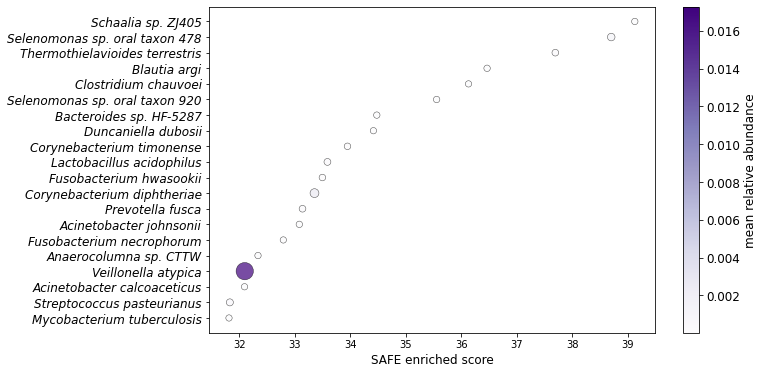

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

df_small = driver_species_20

plt.figure(figsize=(10, 6))

norm = mcolors.Normalize(vmin=driver_species_20['mean_relative_abundance'].min(), 
                         vmax=driver_species_20['mean_relative_abundance'].max())

scatter = sns.scatterplot(
    data=df_small,
    y=df_small.index,  # Microbes on y-axis
    x="SAFE enriched score",  # Score on x-axis
    size="mean_relative_abundance",  # Dot size based on mean abundance
    sizes=(40, 300),  # Adjust dot size range
    alpha=0.7,
    hue="mean_relative_abundance",  # Color the dots by abundance (optional)
    palette="Purples",  # Optional: change palette
    edgecolor="black",  # Circle borders are black
    linewidth=0.5,  # Set the thickness of the border
    legend=None,  # Disable automatic legend
)

sm = plt.cm.ScalarMappable(cmap="Purples", norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm)
cbar.set_label("mean relative abundance", size=12)
cbar.ax.tick_params(labelsize=12)

plt.xticks()  
plt.xlabel("SAFE enriched score", size=12)
plt.ylabel("")
plt.gca().tick_params(axis='y', labelsize=12) 
plt.gca().yaxis.set_tick_params(labelrotation=0)
for label in plt.gca().get_yticklabels():
    label.set_fontstyle('italic')

plt.savefig('Driver_species_MT_SC_BAL_0405_new_clr.pdf', bbox_inches='tight')

In [78]:
edges_df_with_relative_abundance = pd.read_csv('edges_df_with_RL_SC_MT_HostT.csv', sep = '\t')

In [79]:
filtered_df = edges_df_with_relative_abundance[edges_df_with_relative_abundance['start'].isin(driver_species_20.index)]

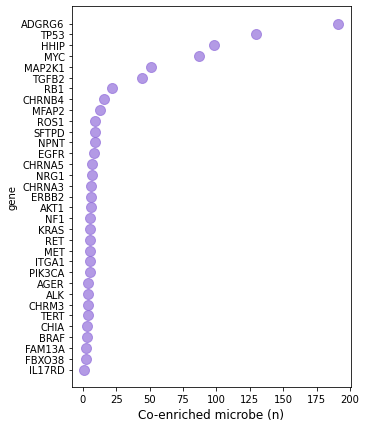

In [83]:
import matplotlib.pyplot as plt

df = edges_df_with_relative_abundance
value_counts = df.iloc[:, 1].value_counts()

sorted_counts = value_counts.sort_values(ascending=True)

plt.figure(figsize=(5, 7))
plt.scatter(sorted_counts.values, sorted_counts.index, color="mediumpurple", s=100, alpha=0.7)
plt.xlabel("Co-enriched microbe (n)", size=12)
plt.ylabel("gene")
plt.title("")
plt.xticks()
plt.grid(axis="y", linestyle="", alpha=0.6)
plt.savefig('MT_coenriched_microbe_n_forgenes_SC_new_clr.pdf',bbox_inches='tight')